# Regression Practice

This notebook is a **quick, practical walkthrough of regression** with scikit-learn.

You will:
- Load a built-in regression dataset (`load_diabetes`)
- Split into train/test sets
- Train a baseline + a regularized linear model (Ridge) in a Pipeline
- Evaluate with **MAE**, **RMSE**, and **$R^2$**
- Visualize predictions and residuals
- Inspect model coefficients (feature effects)

Note: This is **regression** (predicting a continuous value), not classification.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: data + modeling
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Scikit-learn: metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling
sns.set_theme(style="whitegrid")

In [2]:
# Load a built-in regression dataset (continuous target).
diabetes = load_diabetes(as_frame=True)

# Features (X) and target (y) as pandas objects for nicer inspection.
X = diabetes.data
y = diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

# Train/test split so evaluation is on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

# Baseline model: predicts the mean of y from training data.
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [3]:
# Ridge regression (linear regression with L2 regularization).
# We standardize features inside the Pipeline so scaling happens correctly.
ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0, random_state=42)),
    ]
 )

ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [5]:
# Evaluate baseline vs Ridge on the test set
y_pred_baseline = baseline.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

def regression_report(y_true, y_pred, label: str) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = pd.DataFrame(
    [
        regression_report(y_test, y_pred_baseline, "Baseline (mean)"),
        regression_report(y_test, y_pred_ridge, "Ridge"),
    ]
 )

results

,model,MAE,RMSE,R2
0,Baseline (mean),64.006461,73.222493,-0.011963
1,Ridge,42.811999,53.777454,0.454147


In [6]:
# Predict for a single example (one row)
single_instance = X_test.iloc[[0]]  # keep as DataFrame (2D)
true_value = y_test.iloc[0]

pred_value = ridge_model.predict(single_instance)[0]

print("Single instance features:")
display(single_instance)
print(f"True target value: {true_value:.3f}")
print(f"Predicted value  : {pred_value:.3f}")

Single instance features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.00522


True target value: 219.000
Predicted value  : 139.863


## Diagnostics: predictions and residuals

A good regression model should:
- Track the target reasonably well (predicted vs actual points near the diagonal)
- Have residuals (errors) centered near 0 without strong patterns

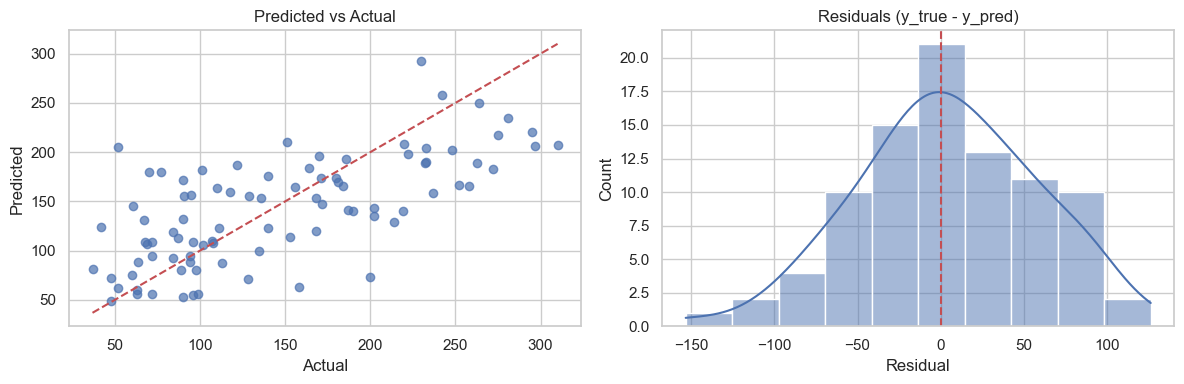

In [7]:
# Recompute predictions (in case you re-run cells out of order)
y_pred = ridge_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--")
axes[0].set_title("Predicted vs Actual")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Residuals distribution
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_title("Residuals (y_true - y_pred)")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## Cross-validation (optional)

Cross-validation gives a more stable estimate than a single train/test split by evaluating the model across multiple folds of the dataset.

In [8]:
# 5-fold cross-validation using R^2 (default for regressors via .score)
cv_r2 = cross_val_score(ridge_model, X, y, cv=5, scoring="r2")
print(f"CV R2: mean={cv_r2.mean():.3f}, std={cv_r2.std():.3f}")

# You can also score with negative MAE (cross_val_score uses 'higher is better')
cv_neg_mae = cross_val_score(ridge_model, X, y, cv=5, scoring="neg_mean_absolute_error")
cv_mae = -cv_neg_mae
print(f"CV MAE: mean={cv_mae.mean():.3f}, std={cv_mae.std():.3f}")

CV R2: mean=0.482, std=0.049
CV MAE: mean=44.265, std=2.031


## Interpreting the model: coefficients

For a linear model like Ridge, each coefficient indicates how the prediction changes (in standardized feature space) when that feature increases, holding others fixed.

Because we used `StandardScaler`, coefficients are comparable in magnitude.

,coefficient
s1,-34.671954
s5,31.378384
bmi,25.732699
s2,17.053075
bp,16.734300
s4,11.764260
sex,-11.448190
s3,3.369914
s6,2.458139
age,1.807342


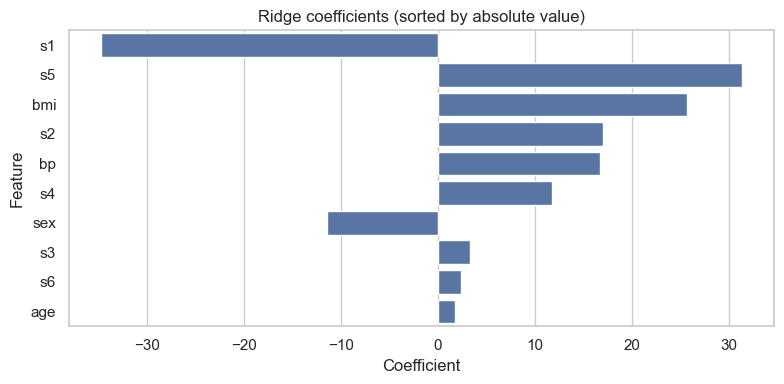

In [9]:
# Extract coefficients from the fitted Pipeline
ridge_estimator = ridge_model.named_steps["ridge"]
coefs = pd.Series(ridge_estimator.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)

display(coefs.to_frame(name="coefficient"))

plt.figure(figsize=(8, 4))
sns.barplot(x=coefs.values, y=coefs.index, orient="h")
plt.title("Ridge coefficients (sorted by absolute value)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()